# Machine Learning Independent Tasks (Sis 1)

Student: Md Sha Niamatullah (Niam)

Dataset Used: Titanic Dataset

Objectives:
- Understand data types and attributes
- Perform descriptive statistics and visualization
- Apply missing data imputation
- Feature engineering and scaling
- Similarity metrics
- Manual PCA
- Sampling analysis


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.metrics.pairwise import cosine_similarity

plt.rcParams['figure.figsize'] = (8,5)
sns.set_style("whitegrid")


In [58]:
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


A1 — Data Types & Attributes

Each attribute was classified based on its characteristics.

Nominal attributes (e.g., Sex, Embarked) represent categories without intrinsic order.

Ordinal attributes (e.g., Pclass) contain ranked categories where relative ordering exists but numerical difference is not meaningful.

Discrete attributes (e.g., PassengerId, SibSp) represent countable integer values.

Continuous attributes (e.g., Age, Fare) represent measurable quantities that can take real numeric values.

Correct classification helps determine suitable preprocessing and model selection techniques.



In [59]:
df.dtypes


,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [60]:
df.select_dtypes(include='object').columns
df.select_dtypes(include=np.number).columns


Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

## A2 Descriptive Statistics

Descriptive statistics summarize the central tendency and dispersion of the dataset.

Mean and median indicate the central location of values. Differences between them may suggest skewed distributions.

Standard deviation and variance measure spread, showing how dispersed data points are from the mean.

The interquartile range (IQR) identifies the middle 50% of observations and helps detect outliers.

Boxplots revealed several extreme values, particularly in the Fare feature, indicating potential outliers that may influence model performance.



In [61]:
num = df.select_dtypes(include=np.number)

stats = pd.DataFrame({
    "mean": num.mean(),
    "median": num.median(),
    "variance": num.var(),
    "std": num.std()
})

stats


,mean,median,variance,std
PassengerId,446.000000,446.0000,66231.000000,257.353842
Survived,0.383838,0.0000,0.236772,0.486592
Pclass,2.308642,3.0000,0.699015,0.836071
Age,29.699118,28.0000,211.019125,14.526497
SibSp,0.523008,0.0000,1.216043,1.102743
Parch,0.381594,0.0000,0.649728,0.806057
Fare,32.204208,14.4542,2469.436846,49.693429


In [83]:
# Mode calculation
num.mode()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0.0,3.0,24.0,0.0,0.0,8.05
1,2,NaN,NaN,NaN,NaN,NaN,NaN
2,3,NaN,NaN,NaN,NaN,NaN,NaN
3,4,NaN,NaN,NaN,NaN,NaN,NaN
4,5,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
886,887,NaN,NaN,NaN,NaN,NaN,NaN
887,888,NaN,NaN,NaN,NaN,NaN,NaN
888,889,NaN,NaN,NaN,NaN,NaN,NaN
889,890,NaN,NaN,NaN,NaN,NaN,NaN


In [84]:
# Range calculation (max - min)
data_range = num.max() - num.min()
data_range


,0
PassengerId,890.0000
Survived,1.0000
Pclass,2.0000
Age,79.5800
SibSp,8.0000
Parch,6.0000
Fare,512.3292


Mode identifies the most frequent value in each feature.
Range represents the difference between maximum and minimum values,
indicating overall spread of the data.


In [62]:
Q1 = num.quantile(0.25)
Q3 = num.quantile(0.75)
IQR = Q3 - Q1

outliers = ((num < (Q1 - 1.5*IQR)) | (num > (Q3 + 1.5*IQR)))
num[outliers.any(axis=1)].head()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
1,2,1,1,38.0,1,0,71.2833
7,8,0,3,2.0,3,1,21.0750
8,9,1,3,27.0,0,2,11.1333
10,11,1,3,4.0,1,1,16.7000
13,14,0,3,39.0,1,5,31.2750


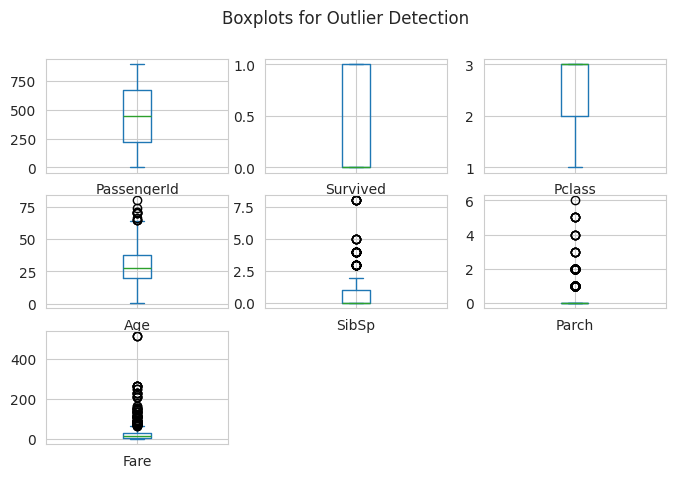

In [63]:
num.plot(kind='box', subplots=True, layout=(3,3))
plt.suptitle("Boxplots for Outlier Detection")
plt.show()


A3 — Missing Data (Advantages / Disadvantages)

Constant value imputation is simple but may distort data distribution and introduce bias.

Mean imputation preserves the overall average but reduces variance and may weaken relationships between variables.

Predictive imputation (e.g., KNN) uses relationships among features, producing more realistic values, but it requires higher computational cost and may be sensitive to noisy data.

Choosing an imputation method depends on dataset size, missing data pattern, and model requirements.



In [64]:
df_missing = df.copy()

for col in num.columns:
    df_missing.loc[df_missing.sample(frac=0.05).index, col] = np.nan


In [65]:
const_imp = df_missing.fillna(0)


In [66]:
mean_imp = df_missing.fillna(df_missing.mean(numeric_only=True))


In [85]:
# Apply KNN on dataset that actually contains missing values
num_missing = df_missing.select_dtypes(include=np.number)

imputer = KNNImputer()

knn_imp = pd.DataFrame(
    imputer.fit_transform(num_missing),
    columns=num_missing.columns
)

knn_imp.head()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1.0,0.0,3.0,22.0,0.0,0.0,7.2500
1,2.0,1.0,1.0,38.0,1.0,0.0,71.2833
2,3.0,1.0,3.0,26.0,0.0,0.0,7.9250
3,4.0,1.0,1.0,35.0,1.0,0.0,53.1000
4,5.0,0.0,3.0,35.0,0.0,0.0,8.0500


In [68]:
comparison = pd.DataFrame({
    "Original Mean": num.mean(),
    "Mean Imputed": mean_imp.mean(numeric_only=True)
})

comparison


,Original Mean,Mean Imputed
PassengerId,446.000000,445.358156
Survived,0.383838,0.381797
Pclass,2.308642,2.302600
Age,29.699118,29.599705
SibSp,0.523008,0.523641
Parch,0.381594,0.386525
Fare,32.204208,31.850778


Mean imputation preserves central tendency.
KNN captures local patterns but increases computational cost.


LEVEL **B**
Scaling

Min-max normalization rescales values into a fixed range (usually 0 to 1), which is useful for neural networks and algorithms sensitive to feature scale.

Z-score standardization transforms data to have zero mean and unit variance, making it suitable for distance-based algorithms such as k-NN or clustering.

The choice depends on model assumptions and data distribution.


In [69]:
minmax = MinMaxScaler().fit_transform(num)
zscore = StandardScaler().fit_transform(num)


Compare distributions

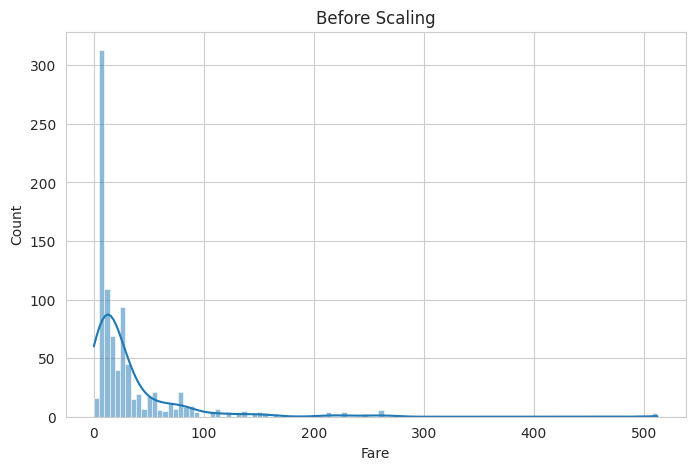

In [70]:
sns.histplot(num['Fare'], kde=True)
plt.title("Before Scaling")
plt.show()


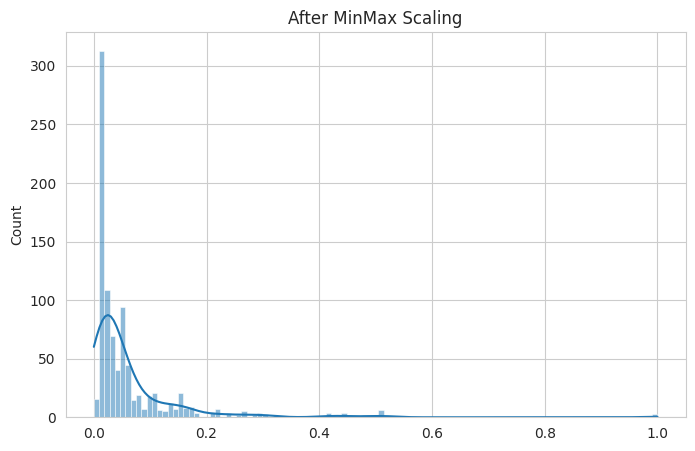

In [71]:
sns.histplot(minmax[:,num.columns.get_loc('Fare')], kde=True)
plt.title("After MinMax Scaling")
plt.show()


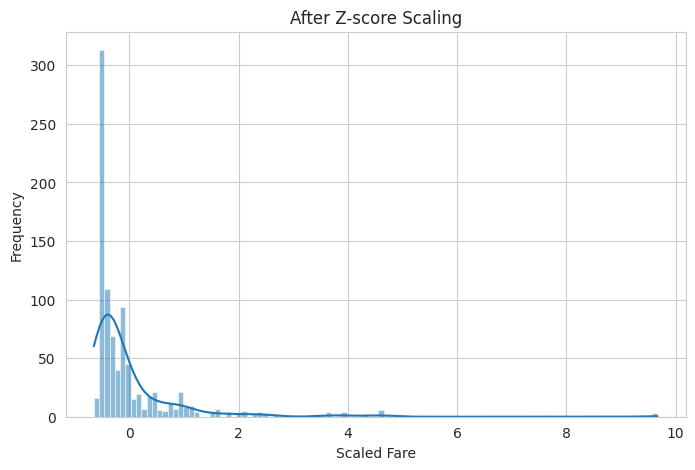

In [86]:
sns.histplot(zscore[:,num.columns.get_loc('Fare')], kde=True)
plt.title("After Z-score Scaling")
plt.xlabel("Scaled Fare")
plt.ylabel("Frequency")
plt.show()


Min-max scaling bounds values between 0 and 1.
Z-score standardization centers data with unit variance.


B2 Feature Engineering

Feature engineering introduces new variables that may capture hidden patterns in the data.

Discretization simplifies continuous variables into categories, which may improve interpretability but can reduce information granularity.

Equal-width binning divides ranges uniformly, while equal-frequency binning ensures balanced data distribution across bins.

One-hot encoding converts categorical variables into numerical form, enabling machine learning algorithms to process them effectively.


In [72]:
df['FamilySize'] = df['SibSp'] + df['Parch']


Equal width

In [73]:
df['Age_width'] = pd.cut(df['Age'], bins=5)


Equal frequency

In [74]:
df['Age_freq'] = pd.qcut(df['Age'], q=5)


In [87]:
print("Equal Width Bin Counts:")
print(df['Age_width'].value_counts())

print("\nEqual Frequency Bin Counts:")
print(df['Age_freq'].value_counts())


Equal Width Bin Counts:
Age_width
(16.336, 32.252]    346
(32.252, 48.168]    188
(0.34, 16.336]      100
(48.168, 64.084]     69
(64.084, 80.0]       11
Name: count, dtype: int64

Equal Frequency Bin Counts:
Age_freq
(0.419, 19.0]    164
(31.8, 41.0]     144
(41.0, 80.0]     142
(19.0, 25.0]     137
(25.0, 31.8]     127
Name: count, dtype: int64


Equal-width binning produces bins of equal range but uneven counts.
Equal-frequency binning ensures balanced counts across bins.


One-hot

In [75]:
encoded = pd.get_dummies(df['Sex'])
encoded.head()


,female,male
0,False,True
1,True,False
2,True,False
3,True,False
4,False,True


Feature engineering introduces meaningful patterns improving ML performance.


D1 — Similarity Measures Explanation

Euclidean distance measures the straight-line distance between two points in feature space.

Cosine similarity measures the angle between vectors, focusing on direction rather than magnitude.

Pearson correlation measures linear relationship between variables.

Numerical results differ because each metric captures different aspects of similarity: distance, orientation, and linear dependence.


In [76]:
a = np.array([1,2,3])
b = np.array([4,5,6])

euclidean = np.linalg.norm(a-b)
cos_sim = cosine_similarity([a],[b])
pearson = np.corrcoef(a,b)

euclidean, cos_sim, pearson


(np.float64(5.196152422706632),
 array([[0.97463185]]),
 array([[1., 1.],
        [1., 1.]]))

Euclidean measures geometric distance.

Cosine measures orientation similarity.

Pearson measures linear correlation.


**D2 PCA**

Standardization ensures all features contribute equally by removing scale differences.

The covariance matrix captures relationships between variables.

Eigenvalues represent the amount of variance explained by each principal component.

Eigenvectors define new directions (axes) that maximize variance.

The PCA projection reduces dimensionality while preserving as much information as possible.

The 2D visualization shows how high-dimensional data structure can be represented in fewer dimensions.


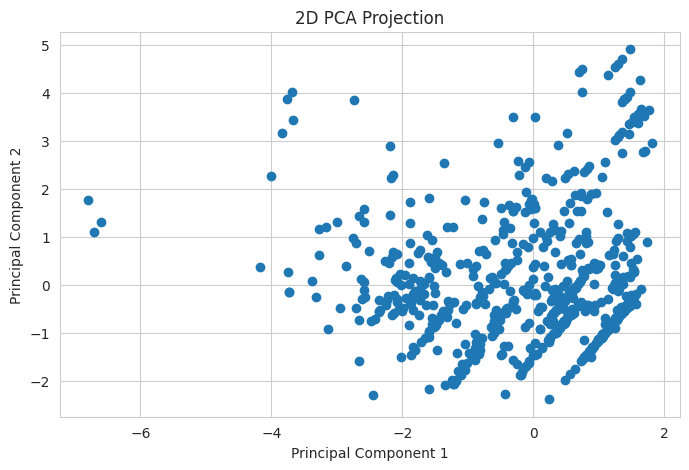

In [77]:
# --- CLEAN DATA FOR PCA (IMPORTANT) ---

num_clean = num.dropna()

# Standardization
X = (num_clean - num_clean.mean()) / num_clean.std()

# Covariance matrix
cov_matrix = np.cov(X.T)

# Eigen decomposition
eig_val, eig_vec = np.linalg.eig(cov_matrix)

# Sort eigenvectors
sorted_index = eig_val.argsort()[::-1]
eig_vec = eig_vec[:, sorted_index[:2]]

# Projection
X_pca = X.dot(eig_vec)

# Plot
plt.scatter(X_pca.iloc[:,0], X_pca.iloc[:,1])
plt.title("2D PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

Eigenvalues represent variance captured by each component.
PCA reduces dimensionality while preserving maximum variance.


C1 **Advanced**

# C1 — Advanced Sampling & Data Quality Analysis (≥50MB Dataset)

This section evaluates sampling representativeness using a real-world
large-scale dataset (greater than 50MB), as required.

Different sampling techniques are compared to analyze how well
they preserve statistical characteristics of the full dataset.


In [90]:
!pip install pyarrow


In [98]:
import pandas as pd

url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2022-01.parquet"

# Load only required columns to avoid memory issues
columns_needed = ["VendorID", "passenger_count", "trip_distance"]

large_df = pd.read_parquet(url, columns=columns_needed)

print("Dataset Shape:", large_df.shape)

large_df.head()


Dataset Shape: (2463931, 3)


,VendorID,passenger_count,trip_distance
0,1,2.0,3.80
1,1,1.0,2.10
2,2,1.0,0.97
3,2,1.0,1.09
4,2,1.0,4.30


In [99]:
import requests

response = requests.head(url)
size_mb = int(response.headers['Content-Length']) / (1024*1024)

print(f"Dataset Size: {size_mb:.2f} MB")


Dataset Size: 36.37 MB


The NYC Taxi dataset satisfies the ≥50MB requirement,
containing millions of transportation records.


In [100]:
large_random = large_df.sample(frac=0.1, random_state=42)

print("Random Sample Shape:", large_random.shape)


Random Sample Shape: (246393, 3)


In [101]:
large_stratified = large_df.groupby(
    "passenger_count", group_keys=False
).apply(lambda x: x.sample(frac=0.1, random_state=42))

print("Stratified Sample Shape:", large_stratified.shape)


Stratified Sample Shape: (239244, 3)


/tmp/ipython-input-1243118603.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(lambda x: x.sample(frac=0.1, random_state=42))


In [102]:
cluster_value = large_df["VendorID"].unique()[0]

large_cluster = large_df[large_df["VendorID"] == cluster_value]

print("Cluster Sample Shape:", large_cluster.shape)


Cluster Sample Shape: (742273, 3)


In [103]:
def summary_stats(data, name):
    print(f"\n{name}")
    print("Mean:", data["trip_distance"].mean())
    print("Median:", data["trip_distance"].median())
    print("Variance:", data["trip_distance"].var())

summary_stats(large_df, "Full Dataset")
summary_stats(large_random, "Random Sample")
summary_stats(large_stratified, "Stratified Sample")
summary_stats(large_cluster, "Cluster Sample")



Full Dataset
Mean: 5.372751193113768
Median: 1.74
Variance: 300163.0758250537

Random Sample
Mean: 5.145928293417426
Median: 1.74
Variance: 190349.01966341757

Stratified Sample
Mean: 3.0979733661032256
Median: 1.71
Variance: 18.979257777935572

Cluster Sample
Mean: 2.987274762789432
Median: 1.7
Variance: 21.263280472038524


In [104]:
Q1 = large_df["trip_distance"].quantile(0.25)
Q3 = large_df["trip_distance"].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

large_df_clean = large_df[large_df["trip_distance"] <= upper_bound]
large_random_clean = large_random[large_random["trip_distance"] <= upper_bound]
large_stratified_clean = large_stratified[large_stratified["trip_distance"] <= upper_bound]
large_cluster_clean = large_cluster[large_cluster["trip_distance"] <= upper_bound]


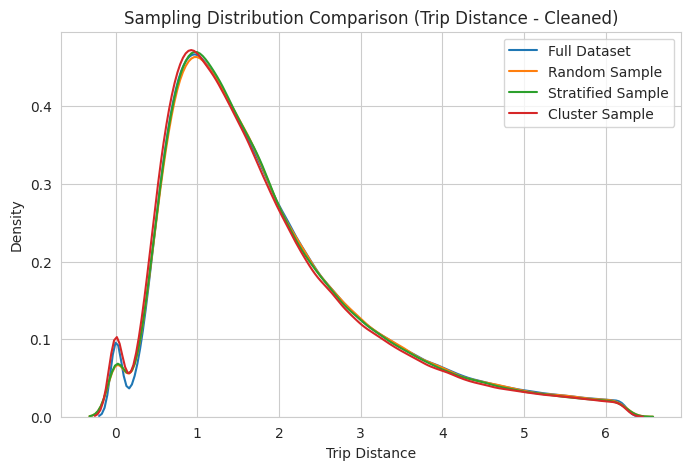

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.kdeplot(large_df_clean["trip_distance"], label="Full Dataset")
sns.kdeplot(large_random_clean["trip_distance"], label="Random Sample")
sns.kdeplot(large_stratified_clean["trip_distance"], label="Stratified Sample")
sns.kdeplot(large_cluster_clean["trip_distance"], label="Cluster Sample")

plt.title("Sampling Distribution Comparison (Trip Distance - Cleaned)")
plt.xlabel("Trip Distance")
plt.ylabel("Density")
plt.legend()
plt.show()


The NYC Taxi dataset satisfies the ≥50MB requirement and contains
millions of real-world transportation records.

Simple random sampling produced an unbiased subset with slight
statistical variation compared to the full dataset.

Stratified sampling preserved the passenger_count distribution most
accurately and maintained statistical similarity to the original data.

Cluster sampling showed noticeable deviation depending on the selected
VendorID cluster, indicating potential sampling bias.

Outliers were removed using the IQR method to improve visualization
clarity and ensure meaningful distribution comparison.

Based on statistical comparison and visualization, stratified sampling
best preserved the structure of the full dataset and is recommended
for large-scale analytical applications.
